# 4. Modélisation supervisée et semi-supervisée avec un CNN entraîné de zéro

Objectif : comparer un entraînement supervisé classique avec deux entraînements semi-supervisés, en utilisant un CNN initialisé aléatoirement et entraîné directement sur les images.

Contrairement à l'ancienne version, le modèle final n'utilise pas ResNet18 préentraîné. Les embeddings ResNet18 déjà calculés servent uniquement à construire les pseudo-labels par clustering.


## Principe expérimental

Trois approches sont comparées :

1. **Supervisé fort uniquement** : le CNN est entraîné de zéro uniquement sur les images fortement labellisées du train.
2. **Semi-supervisé KMeans** : le CNN est d'abord entraîné sur les images faiblement labellisées par KMeans, puis l'entraînement continue sur les images fortement labellisées.
3. **Semi-supervisé DBSCAN** : même protocole, avec les pseudo-labels issus de DBSCAN.

Le jeu de test contient uniquement des labels forts et n'est jamais utilisé pour créer les pseudo-labels ni pour entraîner le modèle.


In [47]:
# Imports
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
OUTPUT_DIR = Path("data/processed")
FEATURES_PATH = OUTPUT_DIR / "resnet18_features.csv"
TEST_SIZE = 0.50

IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0

STRONG_EPOCHS = 20
WEAK_PRETRAIN_EPOCHS = 8
FINETUNE_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

LABEL_TO_ID = {"normal": 0, "cancer": 1}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


Device: cpu


In [48]:
# Load metadata and embeddings used only for pseudo-label selection
features_df = pd.read_csv(FEATURES_PATH)
feature_columns = [col for col in features_df.columns if col.startswith("feature_")]

features_df["path"] = features_df["path"].astype(str)
strong_df = features_df[features_df["label"].isin(["normal", "cancer"])].copy()
unknown_df = features_df[features_df["label"].eq("unknown")].copy()

print("Strong labeled images:", strong_df.shape)
print(strong_df["label"].value_counts())
print("Unlabeled images:", unknown_df.shape)
print("Embedding features for clustering:", len(feature_columns))


Strong labeled images: (100, 515)
label
cancer    50
normal    50
Name: count, dtype: int64
Unlabeled images: (1406, 515)
Embedding features for clustering: 512


## Préparation des images

Le CNN est entraîné à partir des images elles-mêmes. Les images sont redimensionnées, converties en tenseurs et normalisées avec une moyenne et un écart-type simples, sans normalisation issue d'un modèle préentraîné.


In [49]:
# Image transforms for a CNN trained from scratch
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class BrainMRIDataset(Dataset):
    def __init__(self, df, label_col="training_label", transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.label_col = label_col
        self.transform = transform or eval_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)
        label = LABEL_TO_ID[row[self.label_col]]
        return image, torch.tensor(label, dtype=torch.long)


def make_loader(df, label_col="training_label", shuffle=False, transform=None):
    dataset = BrainMRIDataset(df, label_col=label_col, transform=transform)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


## Architecture CNN

Le modèle est volontairement simple pour rester adapté à un petit jeu fortement labellisé. Il est initialisé de zéro à chaque expérience : aucune couche préentraînée n'est utilisée.


In [50]:
# Small CNN initialized from scratch
class SmallBrainCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def make_cnn():
    set_seed()
    return SmallBrainCNN(num_classes=len(LABEL_TO_ID)).to(device)


def train_one_phase(model, train_df, epochs, phase_name, label_col="training_label", lr=LEARNING_RATE):
    loader = make_loader(train_df, label_col=label_col, shuffle=True, transform=train_transform)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_seen = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_seen += batch_size

        history.append({
            "phase": phase_name,
            "epoch": epoch,
            "loss": total_loss / max(total_seen, 1),
            "accuracy": total_correct / max(total_seen, 1),
        })

    return pd.DataFrame(history)


def predict_cnn(model, df, label_col="label"):
    loader = make_loader(df, label_col=label_col, shuffle=False, transform=eval_transform)
    model.eval()
    predictions = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            logits = model(images)
            pred_ids = logits.argmax(dim=1).cpu().numpy()
            predictions.extend([ID_TO_LABEL[int(pred_id)] for pred_id in pred_ids])

    return np.array(predictions)


def compute_metrics(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "recall_cancer": recall_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "precision_cancer": precision_score(y_true, y_pred, pos_label="cancer", zero_division=0),
    }


def evaluate_cnn(model, test_df, model_name):
    y_true = test_df["label"].values
    y_pred = predict_cnn(model, test_df, label_col="label")
    metrics = compute_metrics(y_true, y_pred, model_name)
    print(model_name)
    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics, y_pred


## Split final équilibré

Le split est stratifié pour conserver le même nombre d'images `normal` et `cancer` dans le train et dans le test. Les images du test restent totalement invisibles pendant l'entraînement.


In [51]:
train_idx, test_idx = train_test_split(
    strong_df.index,
    test_size=TEST_SIZE,
    stratify=strong_df["label"],
    random_state=RANDOM_STATE,
)

train_strong_df = strong_df.loc[train_idx].copy()
test_strong_df = strong_df.loc[test_idx].copy()
train_strong_df["training_label"] = train_strong_df["label"]

y_test = test_strong_df["label"].values

print("Strong train labels:")
print(train_strong_df["label"].value_counts())
print("Strong test labels:")
print(test_strong_df["label"].value_counts())


Strong train labels:
label
cancer    25
normal    25
Name: count, dtype: int64
Strong test labels:
label
normal    25
cancer    25
Name: count, dtype: int64


## Baseline supervisée

La baseline entraîne un CNN de zéro uniquement sur le jeu fortement labellisé du train. C'est la référence à battre pour les deux approches semi-supervisées.


In [52]:
# Supervised baseline: train from scratch on strong labels only
supervised_model = make_cnn()
supervised_history = train_one_phase(
    supervised_model,
    train_strong_df,
    epochs=STRONG_EPOCHS,
    phase_name="strong_supervised",
)
supervised_metrics, supervised_pred = evaluate_cnn(
    supervised_model,
    test_strong_df,
    "supervised_strong_only_cnn",
)
supervised_metrics


supervised_strong_only_cnn
              precision    recall  f1-score   support

      cancer       0.53      1.00      0.69        25
      normal       1.00      0.12      0.21        25

    accuracy                           0.56        50
   macro avg       0.77      0.56      0.45        50
weighted avg       0.77      0.56      0.45        50



{'model': 'supervised_strong_only_cnn',
 'accuracy': 0.56,
 'precision_macro': 0.7659574468085106,
 'recall_macro': 0.56,
 'f1_macro': 0.45436507936507936,
 'f1_cancer': 0.6944444444444444,
 'recall_cancer': 1.0,
 'precision_cancer': 0.5319148936170213}

## Pseudo-labellisation sélective

Les pseudo-labels sont construits à partir des embeddings existants. Pour éviter les fuites de données, les clusters sont caractérisés uniquement avec les labels forts du train, jamais avec ceux du test.


In [53]:
def assign_clusters(df, feature_columns, method, **config):
    X = df[feature_columns].values

    if method == "kmeans":
        clustering_model = make_pipeline(
            StandardScaler(),
            KMeans(n_clusters=config["k"], random_state=RANDOM_STATE, n_init=10),
        )
        return clustering_model.fit_predict(X)

    if method == "dbscan":
        clustering_model = make_pipeline(
            StandardScaler(),
            DBSCAN(eps=config["eps"], min_samples=config["min_samples"]),
        )
        return clustering_model.fit_predict(X)

    raise ValueError(f"Unknown clustering method: {method}")


def build_selective_pseudo_labels(
    train_strong_df,
    unknown_df,
    feature_columns,
    method,
    purity_threshold=0.95,
    min_labeled_per_cluster=2,
    mode="both",
    **cluster_config,
):
    pseudo_source_df = pd.concat([train_strong_df, unknown_df], axis=0).copy()
    pseudo_source_df["cluster_modeling"] = assign_clusters(
        pseudo_source_df,
        feature_columns,
        method=method,
        **cluster_config,
    )

    if method == "dbscan":
        pseudo_source_df = pseudo_source_df[pseudo_source_df["cluster_modeling"].ne(-1)].copy()

    train_with_clusters = pseudo_source_df[pseudo_source_df["label"].isin(["normal", "cancer"])].copy()
    unknown_with_clusters = pseudo_source_df[pseudo_source_df["label"].eq("unknown")].copy()

    cluster_counts = pd.crosstab(train_with_clusters["cluster_modeling"], train_with_clusters["label"])

    for label in ["cancer", "normal"]:
        if label not in cluster_counts.columns:
            cluster_counts[label] = 0

    cluster_counts = cluster_counts[["cancer", "normal"]]
    cluster_stats = cluster_counts.copy()
    cluster_stats["n_labeled"] = cluster_stats.sum(axis=1)
    cluster_stats["majority_label"] = cluster_counts.idxmax(axis=1)
    cluster_stats["purity"] = cluster_counts.max(axis=1) / cluster_stats["n_labeled"]

    selected_clusters = cluster_stats[
        (cluster_stats["n_labeled"] >= min_labeled_per_cluster)
        & (cluster_stats["purity"] >= purity_threshold)
    ].copy()

    if mode == "cancer_only":
        selected_clusters = selected_clusters[selected_clusters["majority_label"].eq("cancer")]

    cluster_to_label = selected_clusters["majority_label"].to_dict()
    cluster_to_purity = selected_clusters["purity"].to_dict()
    cluster_to_n = selected_clusters["n_labeled"].to_dict()

    unknown_with_clusters["pseudo_label"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_label)
    unknown_with_clusters["cluster_purity"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_purity)
    unknown_with_clusters["cluster_labeled_count"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_n)

    pseudo_labeled_df = unknown_with_clusters.dropna(subset=["pseudo_label"]).copy()
    pseudo_labeled_df["training_label"] = pseudo_labeled_df["pseudo_label"]

    return pseudo_labeled_df, cluster_stats, selected_clusters


In [54]:
KMEANS_CONFIG = {
    "method": "kmeans",
    "k": 10,
    "purity_threshold": 0.95,
    "min_labeled_per_cluster": 2,
    "mode": "both",
}

DBSCAN_CONFIG = {
    "method": "dbscan",
    "eps": 21.5,
    "min_samples": 12,
    "purity_threshold": 0.95,
    "min_labeled_per_cluster": 2,
    "mode": "both",
}

MODEL_CONFIGS = {
    "kmeans_selective": KMEANS_CONFIG,
    "dbscan_selective": DBSCAN_CONFIG,
}


## Entraînement semi-supervisé

Pour chaque méthode de pseudo-labellisation, le même CNN est entraîné en deux phases :

1. pré-entraînement sur les images faiblement labellisées ;
2. poursuite de l'entraînement sur les images fortement labellisées.

Cette procédure correspond à la consigne du projet : apprendre d'abord sur le jeu faiblement labellisé, puis consolider sur le jeu fortement labellisé.


In [55]:
def fit_semi_supervised_cnn(train_strong_df, unknown_df, config, model_name):
    pseudo_labeled_df, cluster_stats, selected_clusters = build_selective_pseudo_labels(
        train_strong_df,
        unknown_df,
        feature_columns,
        **config,
    )

    print(f"{model_name}: {len(pseudo_labeled_df)} pseudo-labels selected")
    print(pseudo_labeled_df["pseudo_label"].value_counts())

    model = make_cnn()
    histories = []

    if len(pseudo_labeled_df) > 0:
        histories.append(
            train_one_phase(
                model,
                pseudo_labeled_df,
                epochs=WEAK_PRETRAIN_EPOCHS,
                phase_name="weak_pseudo_pretraining",
            )
        )

    histories.append(
        train_one_phase(
            model,
            train_strong_df,
            epochs=FINETUNE_EPOCHS,
            phase_name="strong_finetuning",
        )
    )

    history = pd.concat(histories, axis=0, ignore_index=True)
    metrics, predictions = evaluate_cnn(model, test_strong_df, model_name)

    return {
        "model": model,
        "history": history,
        "metrics": metrics,
        "predictions": predictions,
        "pseudo_labeled_df": pseudo_labeled_df,
        "cluster_stats": cluster_stats,
        "selected_clusters": selected_clusters,
    }


In [56]:
# Semi-supervised split-final comparison
semi_results = {}

for model_name, config in MODEL_CONFIGS.items():
    semi_results[model_name] = fit_semi_supervised_cnn(
        train_strong_df,
        unknown_df,
        config,
        f"semi_supervised_{model_name}_cnn",
    )


semi_supervised_kmeans_selective_cnn: 966 pseudo-labels selected
pseudo_label
cancer    767
normal    199
Name: count, dtype: int64
semi_supervised_kmeans_selective_cnn
              precision    recall  f1-score   support

      cancer       0.96      0.92      0.94        25
      normal       0.92      0.96      0.94        25

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50

semi_supervised_dbscan_selective_cnn: 322 pseudo-labels selected
pseudo_label
cancer    322
Name: count, dtype: int64
semi_supervised_dbscan_selective_cnn
              precision    recall  f1-score   support

      cancer       0.84      0.84      0.84        25
      normal       0.84      0.84      0.84        25

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50



In [57]:
# Leakage check: no test image can appear in any training set
test_paths = set(test_strong_df["path"])

for model_name, result in semi_results.items():
    weak_paths = set(result["pseudo_labeled_df"]["path"])
    strong_paths = set(train_strong_df["path"])
    overlap = test_paths.intersection(weak_paths.union(strong_paths))
    print(model_name, "test/train overlap:", len(overlap))
    assert len(overlap) == 0


kmeans_selective test/train overlap: 0
dbscan_selective test/train overlap: 0


In [58]:
metrics_df = pd.DataFrame(
    [supervised_metrics] + [result["metrics"] for result in semi_results.values()]
)
metrics_df


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_cancer,recall_cancer,precision_cancer
0,supervised_strong_only_cnn,0.56,0.765957,0.56,0.454365,0.694444,1.00,0.531915
1,semi_supervised_kmeans_selective_cnn,0.94,0.940705,0.94,0.939976,0.938776,0.92,0.958333
2,semi_supervised_dbscan_selective_cnn,0.84,0.840000,0.84,0.840000,0.840000,0.84,0.840000


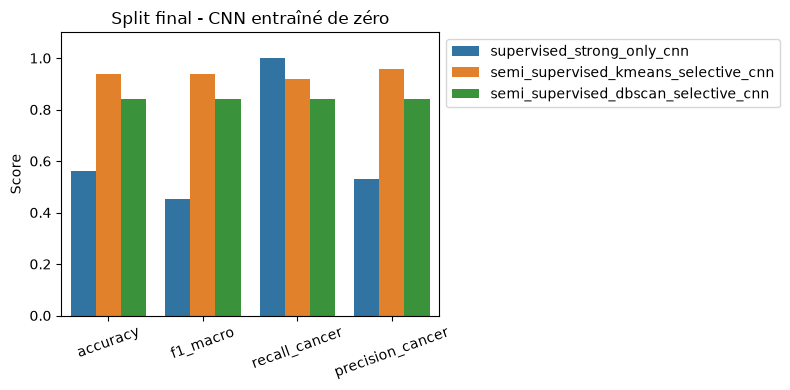

In [70]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_macro", "recall_cancer", "precision_cancer"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="metric", y="score", hue="model", ax=ax)
ax.set_ylim(0, 1.1)
ax.set_title("Split final - CNN entraîné de zéro")
ax.set_xlabel("")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Validation croisée

La validation croisée à cinq plis donne une estimation plus robuste que le split final. À chaque pli, les pseudo-labels sont recalculés uniquement à partir du train fort du pli et des images non labellisées.


In [60]:
def metric_row(fold, model_name, y_true, y_pred, extra=None):
    row = {
        "fold": fold,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "recall_cancer": recall_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "precision_cancer": precision_score(y_true, y_pred, pos_label="cancer", zero_division=0),
    }
    if extra:
        row.update(extra)
    return row


def supervised_cv_cnn(strong_df, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(strong_df, y), start=1):
        print(f"Fold {fold} - supervised CNN")
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()
        train_fold["training_label"] = train_fold["label"]

        model = make_cnn()
        train_one_phase(model, train_fold, epochs=STRONG_EPOCHS, phase_name="strong_supervised")
        y_pred = predict_cnn(model, test_fold, label_col="label")

        results.append(metric_row(
            fold,
            "supervised_strong_only_cnn_cv",
            test_fold["label"].values,
            y_pred,
            {
                "n_pseudo": 0,
                "n_pseudo_cancer": 0,
                "n_pseudo_normal": 0,
                "n_selected_clusters": 0,
            },
        ))

    return pd.DataFrame(results)


def semi_supervised_cv_cnn(strong_df, unknown_df, config, model_name, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(strong_df, y), start=1):
        print(f"Fold {fold} - {model_name}")
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()
        train_fold["training_label"] = train_fold["label"]

        pseudo_labeled_fold, _, selected_clusters_fold = build_selective_pseudo_labels(
            train_fold,
            unknown_df,
            feature_columns,
            **config,
        )

        overlap = set(test_fold["path"]).intersection(
            set(train_fold["path"]).union(set(pseudo_labeled_fold["path"]))
        )
        assert len(overlap) == 0

        model = make_cnn()
        if len(pseudo_labeled_fold) > 0:
            train_one_phase(model, pseudo_labeled_fold, epochs=WEAK_PRETRAIN_EPOCHS, phase_name="weak_pseudo_pretraining")
        train_one_phase(model, train_fold, epochs=FINETUNE_EPOCHS, phase_name="strong_finetuning")

        y_pred = predict_cnn(model, test_fold, label_col="label")
        pseudo_counts = pseudo_labeled_fold["pseudo_label"].value_counts()

        results.append(metric_row(
            fold,
            model_name,
            test_fold["label"].values,
            y_pred,
            {
                "n_pseudo": len(pseudo_labeled_fold),
                "n_pseudo_cancer": pseudo_counts.get("cancer", 0),
                "n_pseudo_normal": pseudo_counts.get("normal", 0),
                "n_selected_clusters": len(selected_clusters_fold),
                "purity_threshold": config["purity_threshold"],
                "min_labeled_per_cluster": config["min_labeled_per_cluster"],
                "clustering_method": config["method"],
            },
        ))

    return pd.DataFrame(results)


In [61]:
# Cross-validation can take time on CPU. Reduce epochs above for a quick smoke test.
supervised_cv_df = supervised_cv_cnn(strong_df)

semi_cv_dfs = []
for model_name, config in MODEL_CONFIGS.items():
    semi_cv_dfs.append(
        semi_supervised_cv_cnn(
            strong_df,
            unknown_df,
            config,
            f"semi_supervised_{model_name}_cnn_cv",
        )
    )

cv_results_df = pd.concat([supervised_cv_df] + semi_cv_dfs, axis=0, ignore_index=True)
cv_results_df


Fold 1 - supervised CNN
Fold 2 - supervised CNN
Fold 3 - supervised CNN
Fold 4 - supervised CNN
Fold 5 - supervised CNN
Fold 1 - semi_supervised_kmeans_selective_cnn_cv
Fold 2 - semi_supervised_kmeans_selective_cnn_cv
Fold 3 - semi_supervised_kmeans_selective_cnn_cv
Fold 4 - semi_supervised_kmeans_selective_cnn_cv
Fold 5 - semi_supervised_kmeans_selective_cnn_cv
Fold 1 - semi_supervised_dbscan_selective_cnn_cv
Fold 2 - semi_supervised_dbscan_selective_cnn_cv
Fold 3 - semi_supervised_dbscan_selective_cnn_cv
Fold 4 - semi_supervised_dbscan_selective_cnn_cv
Fold 5 - semi_supervised_dbscan_selective_cnn_cv


,fold,model,accuracy,f1_macro,f1_cancer,recall_cancer,precision_cancer,n_pseudo,n_pseudo_cancer,n_pseudo_normal,n_selected_clusters,purity_threshold,min_labeled_per_cluster,clustering_method
0,1,supervised_strong_only_cnn_cv,0.55,0.435737,0.689655,1.0,0.526316,0,0,0,0,NaN,NaN,NaN
1,2,supervised_strong_only_cnn_cv,0.75,0.733333,0.800000,1.0,0.666667,0,0,0,0,NaN,NaN,NaN
2,3,supervised_strong_only_cnn_cv,0.65,0.601140,0.740741,1.0,0.588235,0,0,0,0,NaN,NaN,NaN
3,4,supervised_strong_only_cnn_cv,0.65,0.601140,0.740741,1.0,0.588235,0,0,0,0,NaN,NaN,NaN
4,5,supervised_strong_only_cnn_cv,0.75,0.733333,0.800000,1.0,0.666667,0,0,0,0,NaN,NaN,NaN
5,1,semi_supervised_kmeans_selective_cnn_cv,0.85,0.849624,0.842105,0.8,0.888889,538,447,91,4,0.95,2.0,kmeans
6,2,semi_supervised_kmeans_selective_cnn_cv,0.90,0.900000,0.900000,0.9,0.900000,479,479,0,3,0.95,2.0,kmeans
7,3,semi_supervised_kmeans_selective_cnn_cv,0.70,0.687500,0.750000,0.9,0.642857,561,447,114,4,0.95,2.0,kmeans
8,4,semi_supervised_kmeans_selective_cnn_cv,0.65,0.601140,0.740741,1.0,0.588235,743,619,124,5,0.95,2.0,kmeans
9,5,semi_supervised_kmeans_selective_cnn_cv,0.95,0.949875,0.952381,1.0,0.909091,691,499,192,5,0.95,2.0,kmeans


In [62]:
cv_summary = (
    cv_results_df
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_std=("f1_macro", "std"),
        recall_cancer_mean=("recall_cancer", "mean"),
        precision_cancer_mean=("precision_cancer", "mean"),
        n_pseudo_mean=("n_pseudo", "mean"),
    )
    .reset_index()
)
cv_summary


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,recall_cancer_mean,precision_cancer_mean,n_pseudo_mean
0,semi_supervised_dbscan_selective_cnn_cv,0.71,0.108397,0.681853,0.131200,0.94,0.661640,263.8
1,semi_supervised_kmeans_selective_cnn_cv,0.81,0.129422,0.797628,0.147562,0.92,0.785814,602.4
2,supervised_strong_only_cnn_cv,0.67,0.083666,0.620937,0.122830,1.00,0.607224,0.0


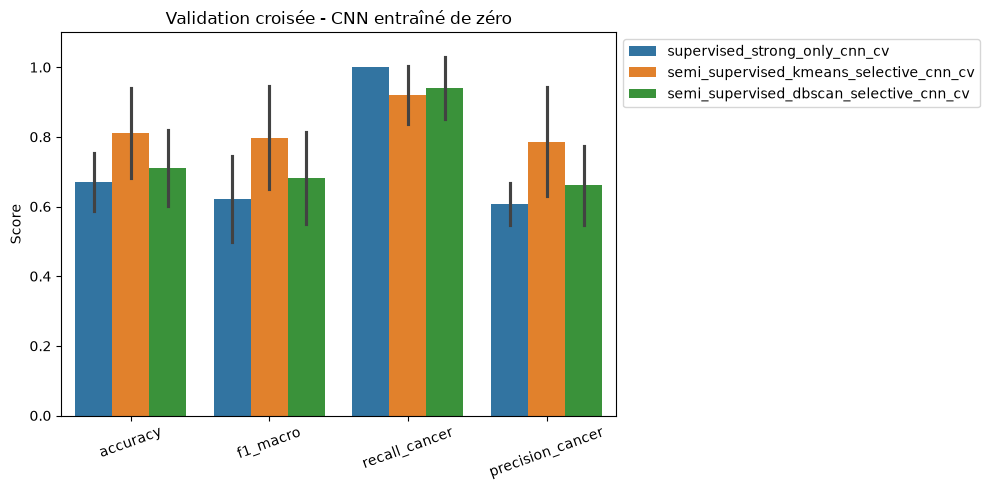

In [66]:
cv_plot_df = cv_results_df.melt(
    id_vars=["fold", "model"],
    value_vars=["accuracy", "f1_macro", "recall_cancer", "precision_cancer"],
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=cv_plot_df, x="metric", y="score", hue="model", errorbar="sd", ax=ax)
ax.set_ylim(0, 1.1)
ax.set_title("Validation croisée - CNN entraîné de zéro")
ax.set_xlabel("")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Interprétation attendue

Cette étape permet de vérifier si un CNN appris de zéro bénéficie réellement des pseudo-labels. La comparaison importante est la suivante :

- si le semi-supervisé dépasse la baseline supervisée, les pseudo-labels apportent un signal utile pour initialiser le CNN ;
- si le semi-supervisé est équivalent, les pseudo-labels ne nuisent pas mais n'apportent pas de gain clair ;
- si le semi-supervisé dégrade les performances, les pseudo-labels sont probablement trop bruités pour un entraînement image de zéro.

La comparaison KMeans contre DBSCAN indique quelle méthode produit les pseudo-labels les plus exploitables pour l'apprentissage du CNN.


In [64]:
# Save outputs without overwriting the logistic-regression notebook outputs
metrics_path = OUTPUT_DIR / "modeling_metrics_scratch_cnn_selective.csv"
cv_results_path = OUTPUT_DIR / "modeling_cv_results_scratch_cnn_selective.csv"
cv_summary_path = OUTPUT_DIR / "modeling_cv_summary_scratch_cnn_selective.csv"

metrics_df.to_csv(metrics_path, index=False)
cv_results_df.to_csv(cv_results_path, index=False)
cv_summary.to_csv(cv_summary_path, index=False)

for model_name, result in semi_results.items():
    prefix = MODEL_CONFIGS[model_name]["method"]
    result["pseudo_labeled_df"].to_csv(
        OUTPUT_DIR / f"pseudo_labels_{prefix}_scratch_cnn_selective.csv",
        index=False,
    )
    result["cluster_stats"].to_csv(
        OUTPUT_DIR / f"{prefix}_cluster_purity_scratch_cnn_modeling.csv",
    )
    result["selected_clusters"].to_csv(
        OUTPUT_DIR / f"{prefix}_selected_clusters_scratch_cnn_modeling.csv",
    )

print("Final split metrics:", metrics_path)
print("CV results:", cv_results_path)
print("CV summary:", cv_summary_path)


Final split metrics: data\processed\modeling_metrics_scratch_cnn_selective.csv
CV results: data\processed\modeling_cv_results_scratch_cnn_selective.csv
CV summary: data\processed\modeling_cv_summary_scratch_cnn_selective.csv


## Definition of Done - étape 4

L'étape 4 est terminée si :

- un CNN initialisé de zéro est entraîné sur les labels forts uniquement ;
- le même type de CNN est entraîné d'abord sur les pseudo-labels, puis sur les labels forts ;
- les deux sources de pseudo-labels, KMeans et DBSCAN, sont comparées ;
- chaque évaluation utilise uniquement des données fortement labellisées jamais vues à l'entraînement ;
- les métriques et les visualisations permettent de comparer clairement supervisé et semi-supervisé.
